In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

In [2]:
import rateslib as rl
import QuantLib as ql

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue, IRSwapValueFunctionMap

# fmt: off
import Query.IRSwaps.adapter  # noqa: F401
# fmt: on

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

# Fetch Curve

In [3]:
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")

In [178]:
curve = "USD-SOFR-1D"
# timestamp = NY_tz.localize(datetime.datetime(2025, 10, 1, 17, 00))
timestamp = "live"

curve_handle = curve_mdp._get_curve(curve_name=curve, timestamp=timestamp)

# risk model
imms = ["Z25", "H26", "M26", "U26", "Z26", "H27", "M27", "U27", "Z27", "H28", "M28", "U28", "Z28"]
sfrs = {}
for imm in imms:
    sfrs[imm] = rl.STIRFuture(
        effective=rl.scheduling.get_imm(code=imm), termination=rl.scheduling.next_imm(rl.scheduling.get_imm(code=imm)), spec="usd_stir", curves=curve_handle.handle()
    )

mt_tenors = ["5Y", "7Y", "10Y", "20Y", "30Y"]
mt_irs = {}
for t in mt_tenors:
    q = IRSwapQuery(curve="USD-SOFR-1D", tenor=t, structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": 1})
    pkg, _ = q.resolve_package(pricer_or_curve=curve_handle)
    mt_irs[t] = pkg[0]

rl_curve_risk_instruments = sfrs | mt_irs
rl_curve_risk_solver = rl.Solver(
    curves=[curve_handle.handle()],
    instruments=rl_curve_risk_instruments.values(),
    instrument_labels=rl_curve_risk_instruments.keys(),
    s=[r.rate().real for r in rl_curve_risk_instruments.values()],
    id=curve_handle.id(),
    func_tol=1e-8,
    conv_tol=1e-10,
)

FETCHING ERIS INTRADAY DISC CURVE...: 100%|██████████| 1/1 [00:00<00:00,  2.68it/s]


SUCCESS: `conv_tol` reached after 12 iterations (levenberg_marquardt), `f_val`: 0.0005906736090884686, `time`: 0.3832s
SUCCESS: `func_tol` reached after 0 iterations (levenberg_marquardt), `f_val`: 0.0, `time`: 0.0041s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1ff4beade50>])

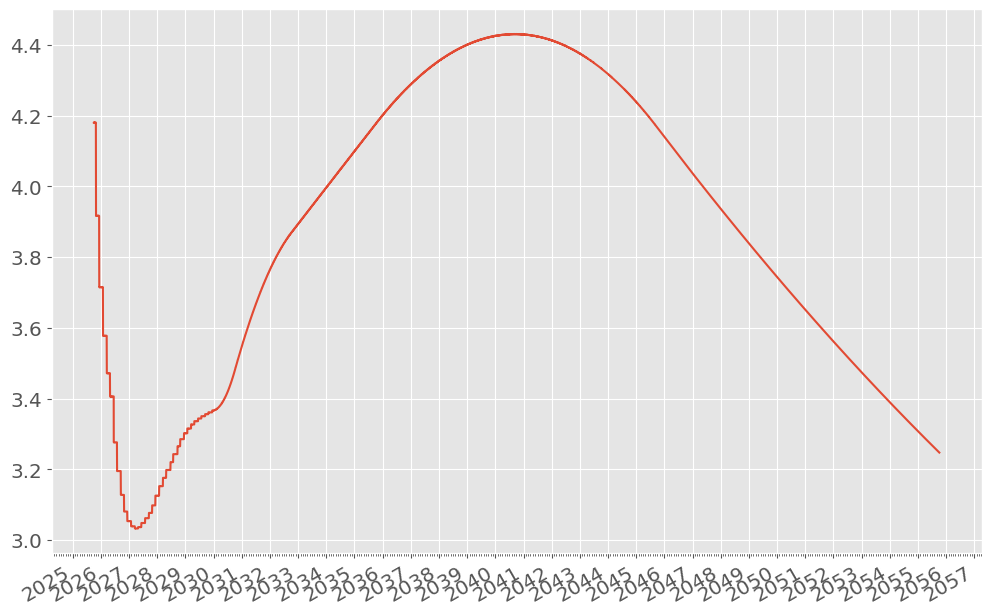

In [179]:
curve_handle.handle().plot("1d")

## Price Outright by tenor

In [134]:
risk = 100_000
outright_query = IRSwapQuery(curve=curve, tenor="10Y", structure=IRSwapStructure.OUTRIGHT, structure_kwargs={"bpv": risk})
outright_pkg, outright_rws = outright_query.resolve_package(pricer_or_curve=curve_handle) 

outright_vmap = outright_query.build_value_map(pricer_or_curve=curve_handle, package=outright_pkg, risk_weights=outright_rws)
for v in [IRSwapValue.RATE, IRSwapValue.NPV, IRSwapValue.NOTIONAL, IRSwapValue.PV01, IRSwapValue.DV01]:
    print(v.name, outright_vmap.apply(value=v))

RATE 3.6331690779097467
NPV 36331690.77909747
NOTIONAL 118786364.94883174
PV01 100000.00000000001


NotImplementedError: rateslib not implemented

In [24]:
# irsvfp.apply(value=IRSwapValue.CARRY_BPS_RUNNING, **{"horizon": "1m"})
# outright_vmap.apply(value=IRSwapValue.CARRY_AND_ROLL_BPS_RUNNING, **{"horizon": "9m"})

# Price Curve

In [38]:
risk = -100_000
curve_query = IRSwapQuery(curve=curve, structure=IRSwapStructure.CURVE, structure_kwargs={"front_tenor": "2Y", "back_tenor": "10Y", "bpv": risk})
curve_pkg, curve_rws = curve_query.resolve_package(pricer_or_curve=curve_handle)

curve_vmap = curve_query.build_value_map(pricer_or_curve=curve_handle, package=curve_pkg, risk_weights=curve_rws)
for v in [IRSwapValue.RATE, IRSwapValue.NPV, IRSwapValue.PV01, IRSwapValue.DV01]:
    print(v.name, curve_vmap.apply(value=v))

RATE 27.324859554040334
NPV -3.725290298461914e-08
PV01 0.0
DV01 708.7816271521151


# Price Fly

In [6]:
def _normalize_leg(s: str) -> str:
    import re
    # grab tenor tokens like 3M, 6m, 1Y, 2y (case-insensitive)
    parts = re.findall(r'\d+\s*[dwmy]', s, flags=re.I)
    parts = [p.upper().replace(" ", "") for p in parts]
    if len(parts) == 1:
        return parts[0]
    if len(parts) == 2:
        return f"{parts[0]}x{parts[1]}"
    raise ValueError(f"Unexpected leg format: {s!r}")


_normalize_leg("10y10y")

'10Yx10Y'

In [53]:
# flies = """ 
# 1y/1y1y/2y1y
# 1y1y/2y1y/3y1y
# 2y1/y3y1/4y1y
# 3y1y/4y1y/5y1y
# 4y1y/5y1y/6y1y
# 5y1y/6y1y/7y1y 
# """

In [ ]:
# for fly_str in flies.split("\n"):
# 	if "/" not in fly_str:
# 		continue

fly_str = "2s" 
wing1, belly, wing2 = fly_str.split("/")

risk = -100_000
fly_query = IRSwapQuery(curve=curve, structure=IRSwapStructure.FLY, structure_kwargs={"front_tenor": wing1, "belly_tenor": belly, "back_tenor": wing2, "bpv": risk})
fly_pkg, fly_rws = fly_query.resolve_package(pricer_or_curve=curve_handle)

fly_vmap = fly_query.build_value_map(pricer_or_curve=curve_handle, package=fly_pkg, risk_weights=fly_rws)
print(fly_str, fly_vmap.apply(value=IRSwapValue.RATE))

display(rl.Portfolio(fly_pkg).delta(solver=rl_curve_risk_solver).style.format("{:_.0f}"))

6y1y/7y1y/8y1y 1.7351303266233824
